# Prediksi Harga Cabai Rawit Merah Kota Bandung dengan CatBoost
**Dataset:** Harga Harian Cabai Rawit Merah + Variabel Iklim Open-Meteo (2022–2026)  
**Metode:** CatBoost Regressor + Optuna (Bayesian Optimization) + Early Stopping  
**Split:** 80% Train : 20% Test (kronologis)


## 1. Instalasi Library

In [1]:
!pip install catboost optuna -q



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\rizal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Import Library

In [2]:
import warnings, calendar, joblib
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import openpyxl

import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


c:\Users\rizal\anaconda3\envs\catboost_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Business Understanding

Harga cabai rawit merah sangat fluktuatif dan berdampak langsung pada inflasi pangan. Penelitian ini membangun model prediksi harga harian cabai rawit merah di Kota Bandung menggunakan data historis harga dan variabel iklim, dengan harapan dapat membantu pedagang, dinas perdagangan, dan konsumen dalam mengantisipasi lonjakan harga.

**Pertanyaan Riset:**
1. Pada jeda waktu (*lag*) berapa variabel iklim berkorelasi paling kuat terhadap harga cabai rawit merah?
2. Seberapa akurat model CatBoost dalam memprediksi harga cabai rawit merah harian?
3. Apakah variabel iklim benar-benar memberikan kontribusi terhadap akurasi prediksi?


## 4. Data Understanding

### 2.1 Load Data Iklim (Open-Meteo, format mentah)

In [3]:
df_iklim_raw = pd.read_excel('Data iklim kota bandung.xlsx', skiprows=3)
print('Total baris :', len(df_iklim_raw))
print('Kolom       :', list(df_iklim_raw.columns))
df_iklim_raw.head()

Total baris : 1671
Kolom       : ['time', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'temperature_2m_mean (°C)', 'precipitation_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)', 'shortwave_radiation_sum (MJ/m²)', 'et0_fao_evapotranspiration (mm)']


,time,temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
0,2022-01-03,28.4,19.9,23.5,0.0,0,8.9,26.20,5.19
1,2022-01-04,27.8,16.1,22.3,0.0,0,13.8,24.12,4.72
2,2022-01-05,28.0,17.7,22.9,4.2,9,14.1,24.28,4.72
3,2022-01-06,27.5,19.3,22.5,3.8,7,12.5,19.56,3.71
4,2022-01-07,26.6,19.4,22.2,8.7,8,12.1,16.41,3.18


### 2.2 Load Data Harga (PIHPS, format wide/transpose per tanggal)

In [4]:
wb = openpyxl.load_workbook('Data harga cabai rawit merah kota bandung.xlsx')
ws = wb.active

print('Nama komoditas :', ws.cell(2, 2).value)
print('Jumlah kolom tanggal :', ws.max_column - 2)
print('Contoh 5 kolom pertama:')
for c in range(3, 8):
    print(' ', ws.cell(1, c).value, '->', ws.cell(2, c).value)

Nama komoditas : Cabai Rawit Merah
Jumlah kolom tanggal : 1195
Contoh 5 kolom pertama:
  03/ 01/ 2022 -> 86,000
  04/ 01/ 2022 -> 86,000
  05/ 01/ 2022 -> 86,000
  06/ 01/ 2022 -> 70,000
  07/ 01/ 2022 -> 70,000


### 2.3 Pengecekan Awal Kualitas Data

Mengecek apakah ada nilai kosong (`'-'`) pada data harga, dan rentang tanggal pada masing-masing sumber data, sebelum dilakukan pembersihan.

In [5]:
jumlah_dash = sum(
    1 for c in range(3, ws.max_column + 1) if ws.cell(2, c).value == '-'
)
print('Jumlah nilai "-" pada data harga :', jumlah_dash)

print('Rentang tanggal data iklim :', df_iklim_raw['time'].min(), '-', df_iklim_raw['time'].max())
print('Rentang tanggal data harga :', ws.cell(1, 3).value, '-', ws.cell(1, ws.max_column).value)

Jumlah nilai "-" pada data harga : 1
Rentang tanggal data iklim : 2022-01-03 00:00:00 - 2026-07-31 00:00:00
Rentang tanggal data harga : 03/ 01/ 2022 - 31/ 07/ 2026


## 5. Data Preparation

### 3.1 Bersihkan Data Iklim: Rename Kolom & Konversi Tipe Tanggal

In [6]:
df_iklim = df_iklim_raw.copy()
df_iklim.columns = ['Tanggal', 'Suhu Max (°C)', 'Suhu Min (°C)', 'Suhu Mean (°C)',
                     'Curah Hujan (mm)', 'Durasi Hujan (jam)', 'Kecepatan Angin Maks (km/h)',
                     'Radiasi Matahari (MJ/m²)', 'Evapotranspirasi ET0 (mm)']
df_iklim['Tanggal'] = pd.to_datetime(df_iklim['Tanggal'])
df_iklim = df_iklim.dropna(subset=['Tanggal']).sort_values('Tanggal').reset_index(drop=True)

print('Total baris iklim setelah dibersihkan:', len(df_iklim))
df_iklim.head()

Total baris iklim setelah dibersihkan: 1671


,Tanggal,Suhu Max (°C),Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam),Kecepatan Angin Maks (km/h),Radiasi Matahari (MJ/m²),Evapotranspirasi ET0 (mm)
0,2022-01-03,28.4,19.9,23.5,0.0,0,8.9,26.20,5.19
1,2022-01-04,27.8,16.1,22.3,0.0,0,13.8,24.12,4.72
2,2022-01-05,28.0,17.7,22.9,4.2,9,14.1,24.28,4.72
3,2022-01-06,27.5,19.3,22.5,3.8,7,12.5,19.56,3.71
4,2022-01-07,26.6,19.4,22.2,8.7,8,12.1,16.41,3.18


### 3.2 Bersihkan Data Harga: Transpose ke Format Long (1 baris = 1 tanggal)

In [7]:
tgl = [ws.cell(1, c).value.replace(' ', '') for c in range(3, ws.max_column + 1)]
harga = [ws.cell(2, c).value for c in range(3, ws.max_column + 1)]

df_harga = pd.DataFrame({
    'Tanggal': pd.to_datetime(tgl, format='%d/%m/%Y'),
    'Harga Cabai Rawit Merah (Rp/kg)': harga
})
df_harga.head()

,Tanggal,Harga Cabai Rawit Merah (Rp/kg)
0,2022-01-03,"86,000"
1,2022-01-04,"86,000"
2,2022-01-05,"86,000"
3,2022-01-06,"70,000"
4,2022-01-07,"70,000"


### 3.3 Bersihkan Data Harga: Konversi Tipe Data & Tangani Nilai Kosong

In [8]:
# '-' -> NaN, hapus koma ribuan, ubah ke tipe numerik
df_harga['Harga Cabai Rawit Merah (Rp/kg)'] = df_harga['Harga Cabai Rawit Merah (Rp/kg)'].replace('-', np.nan)
df_harga['Harga Cabai Rawit Merah (Rp/kg)'] = df_harga['Harga Cabai Rawit Merah (Rp/kg)'].astype(str).str.replace(',', '')
df_harga['Harga Cabai Rawit Merah (Rp/kg)'] = pd.to_numeric(df_harga['Harga Cabai Rawit Merah (Rp/kg)'], errors='coerce')

sebelum = df_harga['Harga Cabai Rawit Merah (Rp/kg)'].isna().sum()
df_harga['Harga Cabai Rawit Merah (Rp/kg)'] = df_harga['Harga Cabai Rawit Merah (Rp/kg)'].interpolate(method='linear')
sesudah = df_harga['Harga Cabai Rawit Merah (Rp/kg)'].isna().sum()

print(f'Missing value sebelum interpolasi : {sebelum}')
print(f'Missing value sesudah interpolasi  : {sesudah}')

df_harga = df_harga.sort_values('Tanggal').reset_index(drop=True)
df_harga.head()

Missing value sebelum interpolasi : 1
Missing value sesudah interpolasi  : 0


,Tanggal,Harga Cabai Rawit Merah (Rp/kg)
0,2022-01-03,86000.0
1,2022-01-04,86000.0
2,2022-01-05,86000.0
3,2022-01-06,70000.0
4,2022-01-07,70000.0


### 3.3b Perluas ke Kalender Penuh & Isi Sabtu-Minggu (Forward Fill)

Data harga PIHPS hanya tersedia pada hari kerja (Senin-Jumat). Pada versi ini, Sabtu dan Minggu diisi dengan **forward fill** — membawa maju harga hari kerja terakhir (Jumat) — sesuai konvensi umum untuk hari non-perdagangan pada data harga/finansial. Setelah langkah ini, seluruh hari (Senin-Minggu) diperlakukan sama rata sebagai satu kalender penuh, tanpa penanda atau perlakuan khusus untuk hari kerja maupun akhir pekan pada tahap selanjutnya. `df_harga` pun berbentuk kalender penuh (7 hari/minggu), sama seperti `df_iklim`, sehingga **data iklim tidak perlu diproses lebih lanjut sebelum digabung** — cukup merge langsung.

In [9]:
df_harga_calendar = df_harga.set_index('Tanggal').asfreq('D')

n_weekend_filled = df_harga_calendar['Harga Cabai Rawit Merah (Rp/kg)'].isna().sum()
print(f'Jumlah baris Sabtu-Minggu yang diisi forward fill: {n_weekend_filled}')

df_harga_calendar['Harga Cabai Rawit Merah (Rp/kg)'] = df_harga_calendar['Harga Cabai Rawit Merah (Rp/kg)'].ffill()

df_harga = df_harga_calendar.reset_index()

print('Total baris data harga setelah diperluas ke kalender penuh:', len(df_harga))
df_harga.head(10)

Jumlah baris Sabtu-Minggu yang diisi forward fill: 476
Total baris data harga setelah diperluas ke kalender penuh: 1671


,Tanggal,Harga Cabai Rawit Merah (Rp/kg)
0,2022-01-03,86000.0
1,2022-01-04,86000.0
2,2022-01-05,86000.0
3,2022-01-06,70000.0
4,2022-01-07,70000.0
5,2022-01-08,70000.0
6,2022-01-09,70000.0
7,2022-01-10,70000.0
8,2022-01-11,70000.0
9,2022-01-12,70000.0


### 3.4 Gabungkan Data Harga & Iklim

Digabungkan berdasarkan tanggal, menggunakan **data harga sebagai acuan** (`how='left'`), karena data harga hanya tersedia pada hari kerja (sesuai jadwal survei PIHPS), sedangkan data iklim tersedia setiap hari kalender.

In [10]:
# df_harga sudah kalender penuh (hasil forward fill di 3.3b), df_iklim juga kalender penuh sejak awal
# -> merge langsung aman, tidak ada baris yang tersaring hilang
df = df_harga.merge(df_iklim, on='Tanggal', how='left')
df = df.sort_values('Tanggal').reset_index(drop=True)

print(f'Total baris data gabungan : {len(df)}')
print(f'Rentang tanggal           : {df["Tanggal"].min().date()} s/d {df["Tanggal"].max().date()}')
df.head()

Total baris data gabungan : 1671
Rentang tanggal           : 2022-01-03 s/d 2026-07-31


,Tanggal,Harga Cabai Rawit Merah (Rp/kg),Suhu Max (°C),Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam),Kecepatan Angin Maks (km/h),Radiasi Matahari (MJ/m²),Evapotranspirasi ET0 (mm)
0,2022-01-03,86000.0,28.4,19.9,23.5,0.0,0,8.9,26.20,5.19
1,2022-01-04,86000.0,27.8,16.1,22.3,0.0,0,13.8,24.12,4.72
2,2022-01-05,86000.0,28.0,17.7,22.9,4.2,9,14.1,24.28,4.72
3,2022-01-06,70000.0,27.5,19.3,22.5,3.8,7,12.5,19.56,3.71
4,2022-01-07,70000.0,26.6,19.4,22.2,8.7,8,12.1,16.41,3.18


### 3.5 Verifikasi Akhir Dataset

In [11]:
print('Missing value per kolom:')
print(df.isna().sum())

print('\nDataset final siap digunakan untuk feature engineering.')
df.tail()

Missing value per kolom:
Tanggal                            0
Harga Cabai Rawit Merah (Rp/kg)    0
Suhu Max (°C)                      0
Suhu Min (°C)                      0
Suhu Mean (°C)                     0
Curah Hujan (mm)                   0
Durasi Hujan (jam)                 0
Kecepatan Angin Maks (km/h)        0
Radiasi Matahari (MJ/m²)           0
Evapotranspirasi ET0 (mm)          0
dtype: int64

Dataset final siap digunakan untuk feature engineering.


,Tanggal,Harga Cabai Rawit Merah (Rp/kg),Suhu Max (°C),Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam),Kecepatan Angin Maks (km/h),Radiasi Matahari (MJ/m²),Evapotranspirasi ET0 (mm)
1666,2026-07-27,45000.0,30.3,15.7,23.1,0.0,0,10.6,21.23,4.66
1667,2026-07-28,45000.0,30.7,16.3,23.6,0.0,0,13.7,21.48,4.66
1668,2026-07-29,45000.0,30.1,18.5,24.2,0.8,5,8.4,21.11,4.35
1669,2026-07-30,39000.0,30.9,19.2,24.6,1.7,5,10.2,20.85,4.29
1670,2026-07-31,39000.0,30.5,19.2,24.6,1.3,3,7.7,20.94,4.34


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Tanggal                          1671 non-null   datetime64[ns]
 1   Harga Cabai Rawit Merah (Rp/kg)  1671 non-null   float64       
 2   Suhu Max (°C)                    1671 non-null   float64       
 3   Suhu Min (°C)                    1671 non-null   float64       
 4   Suhu Mean (°C)                   1671 non-null   float64       
 5   Curah Hujan (mm)                 1671 non-null   float64       
 6   Durasi Hujan (jam)               1671 non-null   int64         
 7   Kecepatan Angin Maks (km/h)      1671 non-null   float64       
 8   Radiasi Matahari (MJ/m²)         1671 non-null   float64       
 9   Evapotranspirasi ET0 (mm)        1671 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 130

In [13]:
df.describe().round(2)

,Tanggal,Harga Cabai Rawit Merah (Rp/kg),Suhu Max (°C),Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam),Kecepatan Angin Maks (km/h),Radiasi Matahari (MJ/m²),Evapotranspirasi ET0 (mm)
count,1671,1671.00,1671.00,1671.00,1671.00,1671.0,1671.00,1671.00,1671.00,1671.00
mean,2024-04-17 00:00:00,49271.24,28.08,19.05,23.05,5.4,6.46,11.60,18.88,3.81
min,2022-01-03 00:00:00,21000.00,22.00,13.90,19.80,0.0,0.00,5.10,4.84,1.09
25%,2023-02-24 12:00:00,34000.00,27.10,18.20,22.50,0.4,2.00,9.40,16.34,3.22
50%,2024-04-17 00:00:00,44000.00,28.00,19.20,23.00,2.0,6.00,11.10,19.21,3.81
75%,2025-06-08 12:00:00,64000.00,29.10,20.10,23.60,7.4,10.00,13.40,21.61,4.35
max,2026-07-31 00:00:00,97500.00,33.50,22.20,26.00,67.1,24.00,24.90,27.78,6.54
std,NaN,19432.48,1.71,1.38,0.83,8.1,5.04,3.12,4.00,0.87


### 5.5 Tren Harga Cabai Rawit Merah (2022–2026)

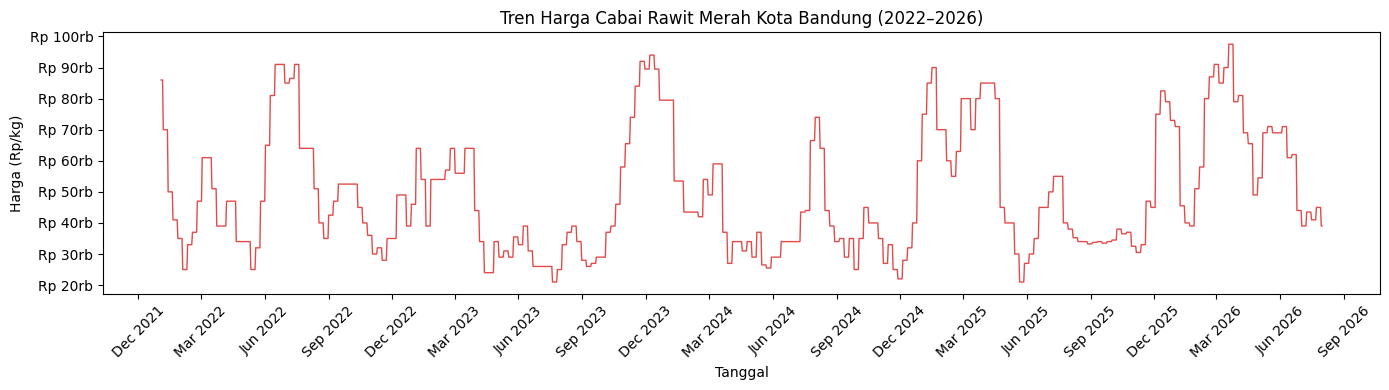

In [14]:
plt.figure(figsize=(14, 4))
plt.plot(df['Tanggal'], df['Harga Cabai Rawit Merah (Rp/kg)'], color='#E24B4A', linewidth=1)
plt.title('Tren Harga Cabai Rawit Merah Kota Bandung (2022–2026)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp/kg)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}rb'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.6 Rata-rata Harga per Bulan dan Tahun

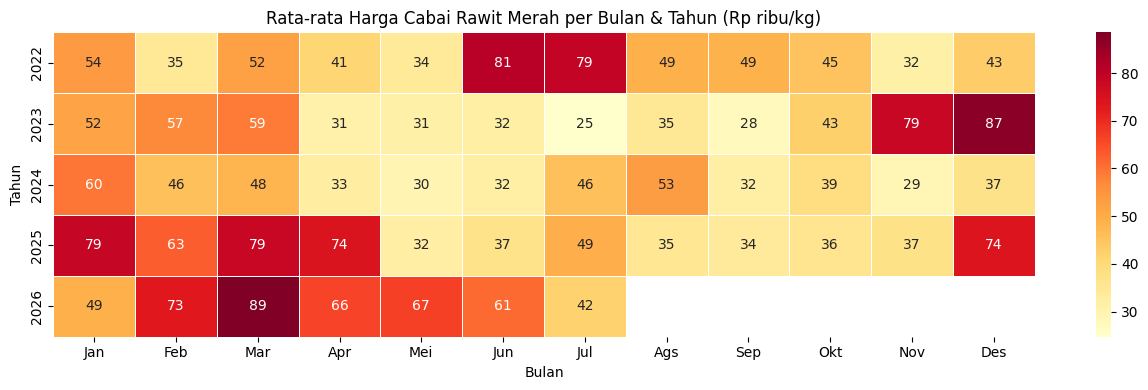

In [15]:
BULAN = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des']
pivot = df.pivot_table(
    values='Harga Cabai Rawit Merah (Rp/kg)',
    index=df['Tanggal'].dt.year,
    columns=df['Tanggal'].dt.month,
    aggfunc='mean'
) / 1000

plt.figure(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', xticklabels=BULAN, linewidths=0.5)
plt.title('Rata-rata Harga Cabai Rawit Merah per Bulan & Tahun (Rp ribu/kg)')
plt.xlabel('Bulan'); plt.ylabel('Tahun')
plt.tight_layout()
plt.show()

### 5.7 Distribusi Variabel Iklim

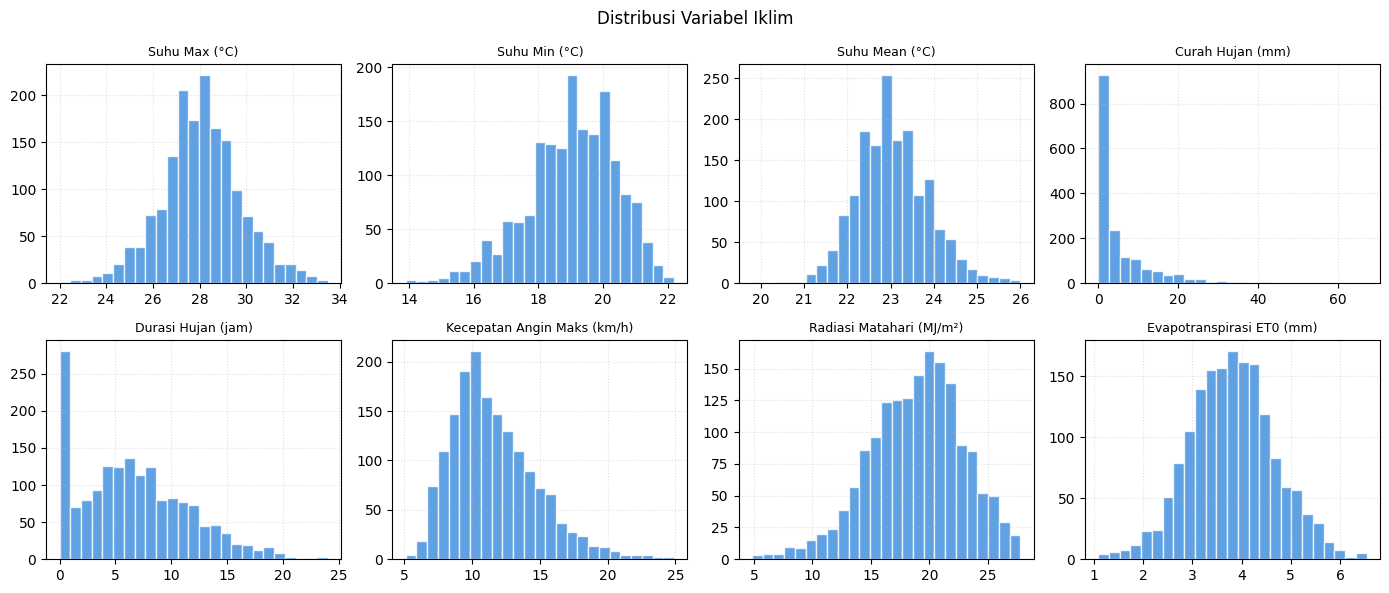

In [16]:
kolom_iklim = [
    'Suhu Max (°C)', 'Suhu Min (°C)', 'Suhu Mean (°C)',
    'Curah Hujan (mm)', 'Durasi Hujan (jam)',
    'Kecepatan Angin Maks (km/h)', 'Radiasi Matahari (MJ/m²)',
    'Evapotranspirasi ET0 (mm)'
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flatten(), kolom_iklim):
    ax.hist(df[col].dropna(), bins=25, color='#378ADD', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.4)
plt.suptitle('Distribusi Variabel Iklim', fontsize=12)
plt.tight_layout()
plt.show()

### 5.8 Korelasi Variabel Iklim

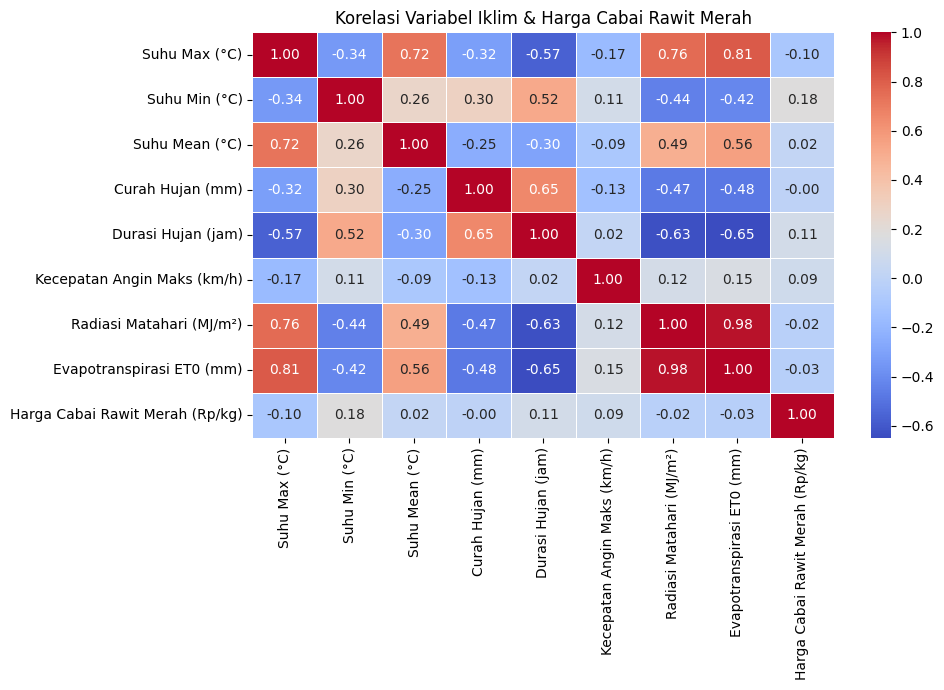

In [17]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[kolom_iklim + ['Harga Cabai Rawit Merah (Rp/kg)']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Variabel Iklim & Harga Cabai Rawit Merah')
plt.tight_layout()
plt.show()

### 5.9 Lag Correlation Analysis

Dalam sektor pertanian, gangguan iklim tidak langsung berdampak pada harga. Tanaman membutuhkan waktu untuk merespons perubahan cuaca, sehingga efek iklim baru terlihat pada harga beberapa hari hingga minggu kemudian. Analisis lag correlation mengukur korelasi variabel iklim beberapa hari sebelumnya terhadap harga hari ini.


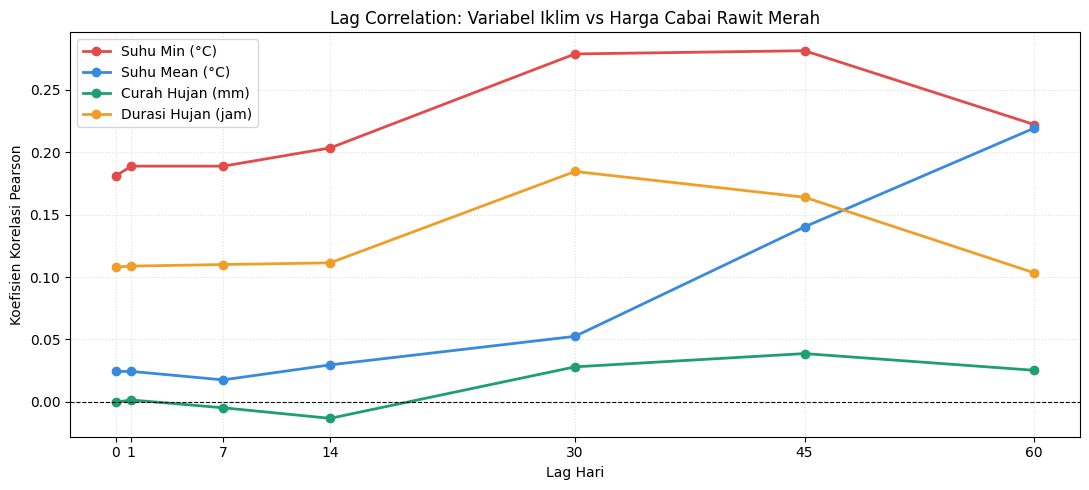

In [18]:
lags = [0, 1, 7, 14, 30, 45, 60]
kolom_uji  = ['Suhu Min (°C)', 'Suhu Mean (°C)', 'Curah Hujan (mm)', 'Durasi Hujan (jam)']
warna      = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27']

lag_corr = {col: [df['Harga Cabai Rawit Merah (Rp/kg)'].corr(df[col].shift(l)) for l in lags]
            for col in kolom_uji}

plt.figure(figsize=(11, 5))
for col, w in zip(kolom_uji, warna):
    plt.plot(lags, lag_corr[col], marker='o', label=col, color=w, linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Lag Correlation: Variabel Iklim vs Harga Cabai Rawit Merah')
plt.xlabel('Lag Hari'); plt.ylabel('Koefisien Korelasi Pearson')
plt.xticks(lags); plt.legend(); plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [19]:
pd.DataFrame(lag_corr, index=[f'lag_{l}' for l in lags]).round(4)

,Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam)
lag_0,0.1811,0.0243,-0.0002,0.1080
lag_1,0.1889,0.0244,0.0014,0.1088
lag_7,0.1889,0.0175,-0.0048,0.1100
lag_14,0.2035,0.0296,-0.0133,0.1114
lag_30,0.2789,0.0525,0.0280,0.1846
lag_45,0.2815,0.1402,0.0386,0.1640
lag_60,0.2223,0.2194,0.0252,0.1034


In [20]:
df.to_excel(
    'dataset harga cabai rawit merah dan iklim kota bandung.xlsx',
    index=False
)
print(f'Dataset gabungan diekspor: {len(df)} baris, {len(df.columns)} kolom')

Dataset gabungan diekspor: 1671 baris, 10 kolom


**Interpretasi:**

Suhu minimum menunjukkan korelasi positif yang meningkat seiring jeda waktu, mencapai puncaknya pada lag 45–60 hari. Pola ini mencerminkan *time-lag effect* pada siklus pertanian cabai rawit merah, di mana kondisi suhu rendah yang dialami tanaman selama fase pembungaan dan pembuahan berdampak pada kualitas dan volume panen 45–60 hari kemudian, yang pada akhirnya mempengaruhi harga di pasar.


### 5.10 Fitur Turunan Iklim

Karena `df_harga` sudah diperluas ke kalender penuh sebelum digabung (lihat 3.3b), `df` hasil merge sekarang sudah kalender penuh juga. Berbeda dari versi sebelumnya, fitur rolling/lag/cumulative pada bagian ini bisa langsung dihitung dari `df` — tidak perlu lagi dihitung dari `df_iklim` secara terpisah sebelum merge, karena tidak ada lagi baris yang "tersaring hilang" saat proses penggabungan.

In [21]:
for w in [7, 14, 30]:
    df[f'SuhuMin_rolling_{w}']    = df['Suhu Min (°C)'].rolling(w).mean()
    df[f'CurahHujan_rolling_{w}'] = df['Curah Hujan (mm)'].rolling(w).mean()
for l in [7, 14, 21, 30, 45, 60]:
    df[f'SuhuMin_lag_{l}'] = df['Suhu Min (°C)'].shift(l)
df['CurahHujan_cum_14'] = df['Curah Hujan (mm)'].rolling(14).sum()
df['CurahHujan_cum_30'] = df['Curah Hujan (mm)'].rolling(30).sum()

print('Fitur iklim turunan berhasil ditambahkan langsung ke df.')
df.filter(like='rolling').join(df.filter(like='lag')).join(df.filter(like='cum')).tail()

Fitur iklim turunan berhasil ditambahkan langsung ke df.


,SuhuMin_rolling_7,CurahHujan_rolling_7,SuhuMin_rolling_14,CurahHujan_rolling_14,SuhuMin_rolling_30,CurahHujan_rolling_30,SuhuMin_lag_7,SuhuMin_lag_14,SuhuMin_lag_21,SuhuMin_lag_30,SuhuMin_lag_45,SuhuMin_lag_60,CurahHujan_cum_14,CurahHujan_cum_30
1666,17.742857,0.242857,17.807143,0.535714,18.023333,0.373333,19.0,16.7,19.4,19.0,18.2,16.8,7.5,11.2
1667,17.200000,0.014286,17.800000,0.514286,17.933333,0.363333,20.1,16.4,19.5,19.0,21.1,17.7,7.2,10.9
1668,17.200000,0.128571,17.900000,0.385714,17.980000,0.390000,18.5,17.1,17.0,17.1,20.0,18.8,5.4,11.7
1669,17.271429,0.357143,17.942857,0.428571,17.996667,0.446667,18.7,18.6,18.8,18.7,19.0,19.6,6.0,13.4
1670,17.514286,0.542857,18.014286,0.457143,18.070000,0.490000,17.5,18.2,16.5,17.0,18.8,19.5,6.4,14.7


### 5.11 Feature Engineering (Harga)

In [22]:
harga = df['Harga Cabai Rawit Merah (Rp/kg)']
for l in [1, 2, 3, 5, 7, 14, 30]:
    df[f'lag_{l}'] = harga.shift(l)

deltas = {'delta_1_3': (1,3), 'delta_1_7': (1,7), 'delta_7_14': (7,14), 'delta_7_30': (7,30), 'momentum_5': (1,5)}
for nama, (a, b) in deltas.items():
    df[nama] = df[f'lag_{a}'] - df[f'lag_{b}']

# Catatan: fitur turunan iklim (SuhuMin_rolling, SuhuMin_lag, CurahHujan_cum, dst) sudah
# dihitung langsung dari df pada Section 5.10, sehingga tidak dihitung ulang di sini.

df['bulan'], df['tahun'] = df['Tanggal'].dt.month, df['Tanggal'].dt.year
TANGGAL_AWAL = df['Tanggal'].min()
df['hari_index']   = (df['Tanggal'] - TANGGAL_AWAL).dt.days
df['target_delta'] = harga - df['lag_1']   # target = delta, bukan harga mentah

df_model = df.dropna().reset_index(drop=True)
print(f'Total data: {len(df_model)} baris')
df_model.head()

Total data: 1611 baris


,Tanggal,Harga Cabai Rawit Merah (Rp/kg),Suhu Max (°C),Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam),Kecepatan Angin Maks (km/h),Radiasi Matahari (MJ/m²),Evapotranspirasi ET0 (mm),...,lag_30,delta_1_3,delta_1_7,delta_7_14,delta_7_30,momentum_5,bulan,tahun,hari_index,target_delta
0,2022-03-04,61000.0,27.1,18.5,22.7,9.9,10,12.3,18.21,3.62,...,35000.0,14000.0,14000.0,10000.0,12000.0,14000.0,3,2022,60,0.0
1,2022-03-05,61000.0,26.0,20.4,22.4,19.3,19,15.6,14.25,2.93,...,25000.0,14000.0,14000.0,10000.0,22000.0,14000.0,3,2022,61,0.0
2,2022-03-06,61000.0,26.6,19.8,22.1,3.3,12,13.3,14.71,3.06,...,25000.0,0.0,14000.0,10000.0,22000.0,14000.0,3,2022,62,0.0
3,2022-03-07,61000.0,26.6,19.6,22.6,3.3,10,11.2,11.22,2.39,...,25000.0,0.0,14000.0,10000.0,22000.0,14000.0,3,2022,63,0.0
4,2022-03-08,61000.0,27.2,18.7,22.4,2.6,7,11.0,16.74,3.35,...,25000.0,0.0,14000.0,10000.0,22000.0,0.0,3,2022,64,0.0


In [23]:
momentum_cols = ['lag_2','lag_3','lag_5','lag_7','lag_14','lag_30',
                  'delta_1_3','delta_1_7','delta_7_14','delta_7_30','momentum_5']
iklim_cols = ['Suhu Max (°C)','Suhu Min (°C)','Suhu Mean (°C)','Curah Hujan (mm)','Durasi Hujan (jam)',
              'Kecepatan Angin Maks (km/h)','Radiasi Matahari (MJ/m²)','Evapotranspirasi ET0 (mm)',
              'SuhuMin_rolling_7','SuhuMin_rolling_14','SuhuMin_rolling_30',
              'CurahHujan_rolling_7','CurahHujan_rolling_14','CurahHujan_rolling_30',
              'SuhuMin_lag_7','SuhuMin_lag_14','SuhuMin_lag_21','SuhuMin_lag_30','SuhuMin_lag_45','SuhuMin_lag_60',
              'CurahHujan_cum_14','CurahHujan_cum_30']
waktu_cols = ['bulan', 'tahun', 'hari_index']
fitur, target = momentum_cols + iklim_cols + waktu_cols, 'target_delta'   # lag_1 TIDAK termasuk fitur

X, y = df_model[fitur], df_model[target]
harga_aktual, lag1_all = df_model['Harga Cabai Rawit Merah (Rp/kg)'], df_model['lag_1']

split_idx = int(len(df_model) * 0.8)   # split kronologis 80:20
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
harga_test_aktual = harga_aktual.iloc[split_idx:].reset_index(drop=True)
lag1_test         = lag1_all.iloc[split_idx:].reset_index(drop=True)

print(f'Data latih: {len(X_train)} | Data uji: {len(X_test)} (mulai {df_model["Tanggal"].iloc[split_idx].date()})')

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Data latih: 1288 | Data uji: 323 (mulai 2025-09-12)


## 6. Modeling

### 6.1 Hyperparameter Tuning (Optuna — Bayesian Optimization)

Tuning dilakukan menggunakan **Optuna** (TPE Sampler), yang mencari kombinasi hyperparameter secara adaptif berdasarkan hasil percobaan sebelumnya. Pendekatan ini memungkinkan eksplorasi ruang nilai kontinu secara lebih efisien, sehingga umumnya menemukan kombinasi hyperparameter yang optimal dengan jumlah percobaan (*trial*) yang relatif sedikit.

| Hyperparameter | Rentang Dicoba |
|---|---|
| `learning_rate` | 0.005 – 0.3 (skala log) |
| `depth` | 2 – 8 |
| `iterations` | 50 – 400 |
| `l2_leaf_reg` | 0.01 – 30 (skala log) |
| `random_strength` | 0.001 – 10 (skala log) |
| `bagging_temperature` | 0.0 – 3.0 |
| `border_count` | 32 – 255 |

Evaluasi tiap trial menggunakan **TimeSeriesSplit** (3-fold) agar validasi tetap menghormati urutan waktu (tidak ada kebocoran data dari masa depan ke masa lalu).


In [24]:
def objective(trial):
    params = {
        'learning_rate'      : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'depth'              : trial.suggest_int('depth', 2, 8),
        'iterations'         : trial.suggest_int('iterations', 50, 400),
        'l2_leaf_reg'        : trial.suggest_float('l2_leaf_reg', 1e-2, 30, log=True),
        'random_strength'    : trial.suggest_float('random_strength', 1e-3, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 3.0),
        'border_count'       : trial.suggest_int('border_count', 32, 255),
    }
    tscv = TimeSeriesSplit(n_splits=3)
    maes = []
    for tr_idx, val_idx in tscv.split(X_train_scaled):
        m = CatBoostRegressor(**params, loss_function='RMSE', random_seed=42, verbose=0)
        m.fit(X_train_scaled[tr_idx], y_train.values[tr_idx])
        pred = m.predict(X_train_scaled[val_idx])
        maes.append(mean_absolute_error(y_train.values[val_idx], pred))
    return float(np.mean(maes))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, timeout=200, show_progress_bar=False)

best = study.best_params
print('Parameter Optuna :', best)
print(f'MAE CV terbaik (pada delta) : Rp {study.best_value:,.0f}/kg')


Parameter Optuna : {'learning_rate': 0.00837852053043704, 'depth': 2, 'iterations': 118, 'l2_leaf_reg': 0.9896285299017878, 'random_strength': 3.952600615548908, 'bagging_temperature': 2.831645499336821, 'border_count': 56}
MAE CV terbaik (pada delta) : Rp 935/kg


### 6.2 Training Model CatBoost

In [25]:
model = CatBoostRegressor(
    **best,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)
model.fit(X_train_scaled, y_train, eval_set=(X_test_scaled, y_test))


0:	learn: 3266.8132204	test: 3670.0972209	best: 3670.0972209 (0)	total: 764us	remaining: 89.5ms
100:	learn: 3247.8036056	test: 3659.4305884	best: 3659.4088963 (99)	total: 94.6ms	remaining: 15.9ms
117:	learn: 3245.0452128	test: 3658.7589296	best: 3658.6772216 (112)	total: 113ms	remaining: 0us

bestTest = 3658.677222
bestIteration = 112

Shrink model to first 113 iterations.


CatBoostRegressor(bagging_temperature=2.831645499336821, border_count=56, depth=2, early_stopping_rounds=50, eval_metric='RMSE', iterations=118, l2_leaf_reg=0.9896285299017878, learning_rate=0.00837852053043704, loss_function='RMSE', random_seed=42, random_strength=3.952600615548908, verbose=100)

### 6.3 Diagnostik Overfitting / Underfitting

Sebelum masuk ke evaluasi akhir, performa model dibandingkan antara **data latih** dan **data uji**. Gap yang kecil antar keduanya menandakan model belajar pola yang general (bukan menghafal data latih); gap yang besar menandakan overfitting.

In [26]:
delta_pred_train = model.predict(X_train_scaled)
delta_pred_test_diag = model.predict(X_test_scaled)

harga_train_aktual = harga_aktual.iloc[:split_idx].reset_index(drop=True)
lag1_train = lag1_all.iloc[:split_idx].reset_index(drop=True)

y_pred_train_diag = lag1_train.values + delta_pred_train
y_pred_test_diag  = lag1_test.values + delta_pred_test_diag

r2_train  = r2_score(harga_train_aktual.values, y_pred_train_diag)
r2_test   = r2_score(harga_test_aktual.values, y_pred_test_diag)
mae_train = mean_absolute_error(harga_train_aktual.values, y_pred_train_diag)
mae_test  = mean_absolute_error(harga_test_aktual.values, y_pred_test_diag)

diagnostik = pd.DataFrame([
    {'Dataset': 'Train', 'R2 Score': round(r2_train, 4), 'MAE (Rp)': round(mae_train, 2)},
    {'Dataset': 'Test',  'R2 Score': round(r2_test, 4),  'MAE (Rp)': round(mae_test, 2)},
])

In [27]:
gap_r2 = r2_train - r2_test

print(diagnostik.to_string(index=False))
print(f"\nGap R² (train - test): {gap_r2:.4f}")

if r2_train > r2_test and gap_r2 > 0.05:
    print("-> Indikasi OVERFITTING.")
elif r2_train < 0.5 and r2_test < 0.5:
    print("-> Indikasi UNDERFITTING.")
else:
    print("-> Model cenderung mampu melakukan generalisasi dengan baik.")

Dataset  R2 Score  MAE (Rp)
  Train    0.9707    939.65
   Test    0.9647   1044.38

Gap R² (train - test): 0.0061
-> Model cenderung mampu melakukan generalisasi dengan baik.


## 7. Evaluasi Model

### 7.1 Evaluasi Kuantitatif

In [28]:
delta_pred = model.predict(X_test_scaled)
y_pred     = lag1_test.values + delta_pred          # rekonstruksi harga dari delta

def hitung_metrik(y_true, y_hat):
    return {
        'MAE (Rp)' : round(mean_absolute_error(y_true, y_hat), 2),
        'RMSE (Rp)': round(np.sqrt(mean_squared_error(y_true, y_hat)), 2),
        'R2 Score' : round(r2_score(y_true, y_hat), 4),
        'MAPE (%)' : round(mean_absolute_percentage_error(y_true, y_hat) * 100, 2)
    }

evaluasi = pd.DataFrame([
    {'Model': 'CatBoost', **hitung_metrik(harga_test_aktual.values, y_pred)}
])
evaluasi

,Model,MAE (Rp),RMSE (Rp),R2 Score,MAPE (%)
0,CatBoost,1044.38,3658.68,0.9647,1.83


### 7.2 Perbandingan dengan Baseline Naif

Baseline naif memprediksi harga hari ini sama dengan harga hari kerja sebelumnya (`y_pred_baseline = lag_1`), tanpa model apa pun. Perbandingan ini penting untuk menilai seberapa besar kontribusi nyata model CatBoost di luar autokorelasi harga yang memang sudah tinggi.

---


In [29]:
y_pred_baseline = lag1_test.values

evaluasi_baseline = pd.DataFrame([
    {'Model': 'Baseline Naif (lag_1)', **hitung_metrik(harga_test_aktual.values, y_pred_baseline)},
    {'Model': 'CatBoost',              **hitung_metrik(harga_test_aktual.values, y_pred)}
])

r2_model    = evaluasi_baseline.loc[evaluasi_baseline['Model'] == 'CatBoost', 'R2 Score'].values[0]
r2_baseline = evaluasi_baseline.loc[evaluasi_baseline['Model'] == 'Baseline Naif (lag_1)', 'R2 Score'].values[0]
pengurangan_error_sisa = (r2_model - r2_baseline) / (1 - r2_baseline) * 100

print(f'Model CatBoost mengurangi error sisa (unexplained variance) sebesar {pengurangan_error_sisa:.1f}% dibanding baseline naif.')
evaluasi_baseline

Model CatBoost mengurangi error sisa (unexplained variance) sebesar 0.8% dibanding baseline naif.


,Model,MAE (Rp),RMSE (Rp),R2 Score,MAPE (%)
0,Baseline Naif (lag_1),969.04,3670.23,0.9644,1.70
1,CatBoost,1044.38,3658.68,0.9647,1.83


### 7.3 Grafik Aktual vs Prediksi



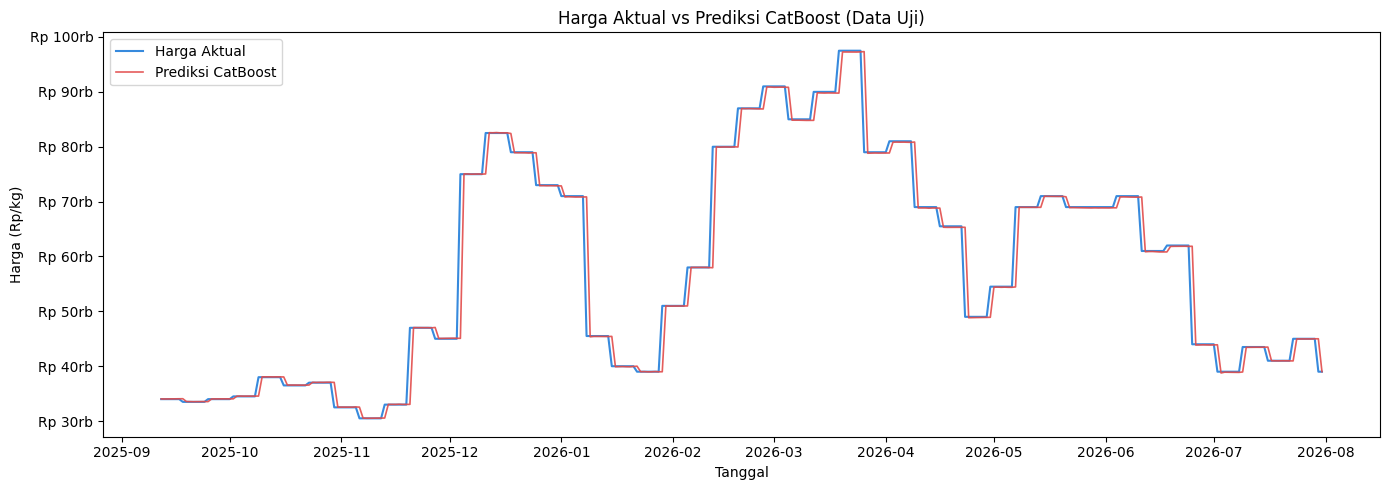

In [30]:
test_dates = df_model['Tanggal'].iloc[split_idx:].values

plt.figure(figsize=(14, 5))
plt.plot(test_dates, harga_test_aktual.values, label='Harga Aktual', color='#378ADD', linewidth=1.5)
plt.plot(test_dates, y_pred, label='Prediksi CatBoost', color='#E24B4A', linewidth=1.2, alpha=0.9)
plt.title('Harga Aktual vs Prediksi CatBoost (Data Uji)')
plt.xlabel('Tanggal'); plt.ylabel('Harga (Rp/kg)')
plt.legend(loc='upper left')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}rb'))
plt.tight_layout()
plt.show()

### 7.4 Tabel Hasil Prediksi

In [31]:
df_hasil = pd.DataFrame({
    'Tanggal'          : pd.to_datetime(test_dates).strftime('%d/%m/%Y'),
    'Harga Aktual'     : harga_test_aktual.values,
    'Harga Prediksi'   : y_pred.round(0),
    'Error (Rp)'       : np.abs(harga_test_aktual.values - y_pred).round(0)
})
df_hasil.head(10)

,Tanggal,Harga Aktual,Harga Prediksi,Error (Rp)
0,12/09/2025,34000.0,34045.0,45.0
1,13/09/2025,34000.0,34027.0,27.0
2,14/09/2025,34000.0,34035.0,35.0
3,15/09/2025,34000.0,34035.0,35.0
4,16/09/2025,34000.0,34051.0,51.0
5,17/09/2025,34000.0,34062.0,62.0
6,18/09/2025,33500.0,34076.0,576.0
7,19/09/2025,33500.0,33564.0,64.0
8,20/09/2025,33500.0,33551.0,51.0
9,21/09/2025,33500.0,33533.0,33.0


### 7.5 Residual Analysis

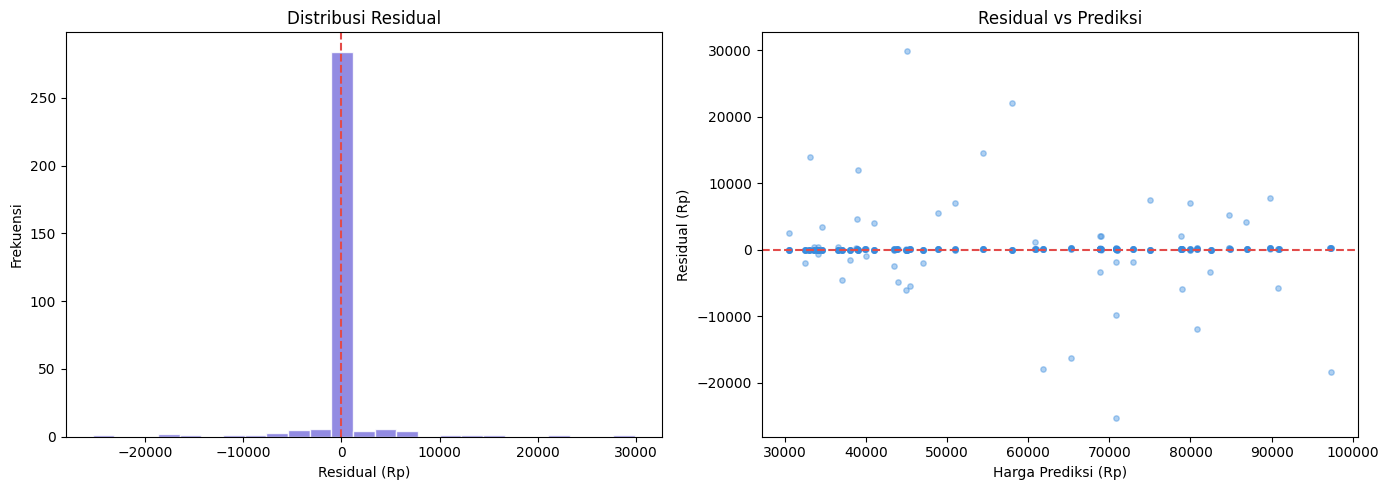

Rata-rata residual : Rp 75.32
Std residual        : Rp 3,657.90


In [32]:
residual = harga_test_aktual.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residual, bins=25, color='#7F77DD', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='#E24B4A', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribusi Residual')
axes[0].set_xlabel('Residual (Rp)'); axes[0].set_ylabel('Frekuensi')

axes[1].scatter(y_pred, residual, alpha=0.4, color='#378ADD', s=15)
axes[1].axhline(0, color='#E24B4A', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual vs Prediksi')
axes[1].set_xlabel('Harga Prediksi (Rp)'); axes[1].set_ylabel('Residual (Rp)')

plt.tight_layout()
plt.show()

print(f'Rata-rata residual : Rp {residual.mean():,.2f}')
print(f'Std residual        : Rp {residual.std():,.2f}')


**Interpretasi:**

Residual positif berarti model *underestimate* (prediksi < aktual), negatif berarti *overestimate*. Rata-rata residual yang mendekati nol menunjukkan tidak ada bias sistematis pada model.



### 7.6 Feature Importance

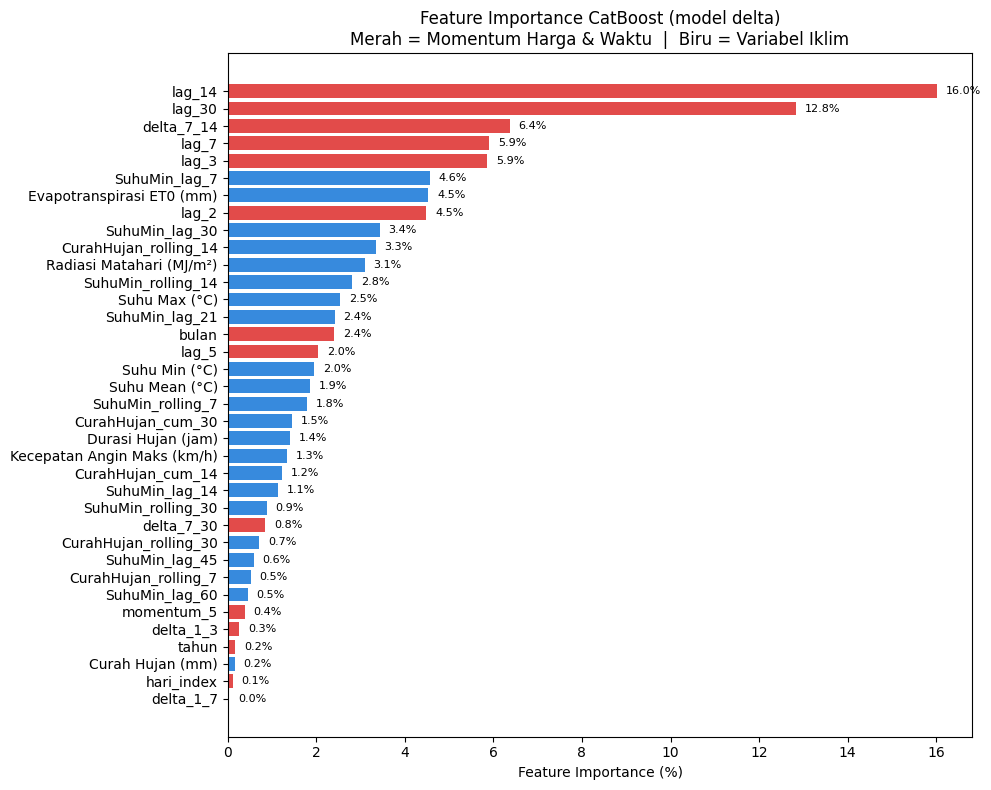

In [33]:
importance = model.get_feature_importance()
feat_df = pd.DataFrame({'Fitur': fitur, 'Importance': importance}).sort_values('Importance', ascending=True)

MOMENTUM = set(momentum_cols) | {'bulan', 'tahun', 'hari_index'}
colors = ['#E24B4A' if f in MOMENTUM else '#378ADD' for f in feat_df['Fitur']]

plt.figure(figsize=(10, 8))
bars = plt.barh(feat_df['Fitur'], feat_df['Importance'], color=colors)
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8)
plt.xlabel('Feature Importance (%)')
plt.title('Feature Importance CatBoost (model delta)\nMerah = Momentum Harga & Waktu  |  Biru = Variabel Iklim')
plt.tight_layout()
plt.show()


## 8. Deployment

### 8.1 Simpan Model

In [34]:
model.save_model('model_catboost_cabai.cbm')
joblib.dump(scaler, 'scaler_cabai.pkl')
joblib.dump(fitur,  'fitur_cabai.pkl')
print('Model, scaler, dan daftar fitur berhasil disimpan.')
print('Catatan: model memprediksi DELTA harga. Saat inference, harga akhir = lag_1 + delta_prediksi.')


Model, scaler, dan daftar fitur berhasil disimpan.
Catatan: model memprediksi DELTA harga. Saat inference, harga akhir = lag_1 + delta_prediksi.


### 8.2 Prediksi Harga Bulanan

Estimasi iklim untuk bulan yang diprediksi dihitung dari **rata-rata historis per tanggal**, disesuaikan dengan **tren tahunan** (regresi linear per variabel iklim terhadap tahun), tanpa bergantung pada API eksternal. Pendekatan ini konsisten untuk semua rentang tanggal, tidak dibatasi jangkauan API forecast/arsip.


In [35]:
NAMA_BULAN = {
    1:'Januari', 2:'Februari', 3:'Maret',  4:'April',
    5:'Mei',     6:'Juni',     7:'Juli',   8:'Agustus',
    9:'September', 10:'Oktober', 11:'November', 12:'Desember'
}

print('Pilih bulan untuk prediksi:')
for k, v in NAMA_BULAN.items():
    print(f'  {k:>2}. {v}')

bulan = int(input('\nMasukkan nomor bulan : '))
tahun = int(input('Masukkan tahun       : '))
print(f'\nPrediksi untuk: {NAMA_BULAN[bulan]} {tahun}')

Pilih bulan untuk prediksi:
   1. Januari
   2. Februari
   3. Maret
   4. April
   5. Mei
   6. Juni
   7. Juli
   8. Agustus
   9. September
  10. Oktober
  11. November
  12. Desember

Prediksi untuk: Agustus 2026


In [36]:
COL_IKLIM = ['Suhu Max (°C)', 'Suhu Min (°C)', 'Suhu Mean (°C)', 'Curah Hujan (mm)',
             'Durasi Hujan (jam)', 'Kecepatan Angin Maks (km/h)',
             'Radiasi Matahari (MJ/m²)', 'Evapotranspirasi ET0 (mm)']

# Tentukan rentang tanggal untuk bulan & tahun yang dipilih
last_day   = calendar.monthrange(tahun, bulan)[1]
start_date = date(tahun, bulan, 1)
end_date   = date(tahun, bulan, last_day)

# Estimasi iklim berbasis rata-rata historis per tanggal, disesuaikan tren tahunan (tanpa API)
df_hist = df[df['Tanggal'].dt.month == bulan]
rata_per_tanggal = df_hist.groupby(df_hist['Tanggal'].dt.day)[COL_IKLIM].mean()
rata_per_tahun   = df_hist.groupby(df_hist['Tanggal'].dt.year)[COL_IKLIM].mean()

# Hitung offset tren tahunan untuk tiap variabel iklim, supaya tahun berbeda -> nilai berbeda
offset = {}
for kolom in COL_IKLIM:
    data_tahunan = rata_per_tahun[kolom].dropna()
    if len(data_tahunan) >= 2:
        slope = np.polyfit(data_tahunan.index, data_tahunan.values, 1)[0]
        offset[kolom] = slope * (tahun - np.mean(data_tahunan.index))
    else:
        offset[kolom] = 0.0

rata_disesuaikan = rata_per_tanggal + pd.Series(offset)

tanggal_range = pd.date_range(str(start_date), str(end_date))   # kalender penuh, konsisten dengan data training
df_iklim = pd.DataFrame({'hari': tanggal_range.day})
df_iklim = df_iklim.merge(rata_disesuaikan.reset_index().rename(columns={'Tanggal': 'hari'}),
                           on='hari', how='left')
df_iklim = df_iklim.fillna(rata_disesuaikan.mean()).drop(columns='hari')
df_iklim['Tanggal'] = tanggal_range
df_iklim['bulan']   = bulan
df_iklim['tahun']   = df_iklim['Tanggal'].dt.year
df_iklim['hari_index'] = (df_iklim['Tanggal'] - TANGGAL_AWAL).dt.days

teks_offset = ', '.join(f'{k}={v:+.2f}' for k, v in offset.items())
MODE = 'EVALUASI' if df['Tanggal'].between(str(start_date), str(end_date)).any() else 'PREDIKSI'
print(f'Estimasi iklim: {len(df_iklim)} hari (offset tahun {tahun}: {teks_offset})')
print(f'Mode: {MODE}')


Estimasi iklim: 31 hari (offset tahun 2026: Suhu Max (°C)=-0.07, Suhu Min (°C)=+0.51, Suhu Mean (°C)=+0.07, Curah Hujan (mm)=+2.32, Durasi Hujan (jam)=+1.99, Kecepatan Angin Maks (km/h)=-0.26, Radiasi Matahari (MJ/m²)=-1.25, Evapotranspirasi ET0 (mm)=-0.19)
Mode: PREDIKSI


In [37]:
# Kumpulan data historis (dipakai sebagai "memori" model saat prediksi maju ke depan)
aktual_dict = df.set_index(df['Tanggal'].dt.date)['Harga Cabai Rawit Merah (Rp/kg)'].to_dict()
harga_buf = list(df[df['Tanggal'] < pd.Timestamp(start_date)]['Harga Cabai Rawit Merah (Rp/kg)'].values)
suhu_buf  = list(df[df['Tanggal'] < pd.Timestamp(start_date)]['Suhu Min (°C)'].values)
hujan_buf = list(df[df['Tanggal'] < pd.Timestamp(start_date)]['Curah Hujan (mm)'].values)


def ambil_lag(buffer, n):
    """Ambil nilai n hari ke belakang dari buffer."""
    if len(buffer) >= n:
        return buffer[-n]
    return buffer[0]


def rata_rata_bergerak(buffer, window):
    """Rata-rata bergerak (rolling mean) dari 'window' hari terakhir di buffer."""
    return float(np.mean(buffer[-window:]))


def total_bergerak(buffer, window):
    """Total kumulatif (rolling sum) dari 'window' hari terakhir di buffer."""
    return float(np.sum(buffer[-window:]))


def ambil_harga(tanggal, hari_ke_belakang):
    """Ambil harga aktual kalau ada, kalau tidak pakai buffer historis."""
    tanggal_target = (pd.Timestamp(tanggal) - pd.Timedelta(hari_ke_belakang, 'D')).date()
    if tanggal_target in aktual_dict:
        return aktual_dict[tanggal_target]
    return ambil_lag(harga_buf, hari_ke_belakang)


rows, pred_list = [], []
for _, row in df_iklim.iterrows():
    tgl    = row['Tanggal'].date()
    aktual = aktual_dict.get(tgl)

    # Ambil harga di beberapa lag yang dibutuhkan
    lag_1  = ambil_harga(tgl, 1)
    lag_2  = ambil_harga(tgl, 2)
    lag_3  = ambil_harga(tgl, 3)
    lag_5  = ambil_harga(tgl, 5)
    lag_7  = ambil_harga(tgl, 7)
    lag_14 = ambil_harga(tgl, 14)
    lag_30 = ambil_harga(tgl, 30)

    # Update buffer iklim dengan data hari ini
    suhu_buf.append(row['Suhu Min (°C)'])
    hujan_buf.append(row['Curah Hujan (mm)'])

    # Susun semua fitur untuk hari ini (harus sama persis dengan fitur saat training)
    fitur_hari_ini = {
        'lag_2': lag_2, 'lag_3': lag_3, 'lag_5': lag_5,
        'lag_7': lag_7, 'lag_14': lag_14, 'lag_30': lag_30,
        'delta_1_3': lag_1 - lag_3, 'delta_1_7': lag_1 - lag_7,
        'delta_7_14': lag_7 - lag_14, 'delta_7_30': lag_7 - lag_30,
        'momentum_5': lag_1 - lag_5,
        'bulan': row['bulan'], 'tahun': row['tahun'], 'hari_index': row['hari_index']
    }
    for kolom in COL_IKLIM:
        fitur_hari_ini[kolom] = row[kolom]
    for w in [7, 14, 30]:
        fitur_hari_ini[f'SuhuMin_rolling_{w}']    = rata_rata_bergerak(suhu_buf, w)
        fitur_hari_ini[f'CurahHujan_rolling_{w}'] = rata_rata_bergerak(hujan_buf, w)
    for l in [7, 14, 21, 30, 45, 60]:
        fitur_hari_ini[f'SuhuMin_lag_{l}'] = ambil_lag(suhu_buf, l)
    fitur_hari_ini['CurahHujan_cum_14'] = total_bergerak(hujan_buf, 14)
    fitur_hari_ini['CurahHujan_cum_30'] = total_bergerak(hujan_buf, 30)

    # Prediksi delta, lalu rekonstruksi jadi harga: harga = lag_1 + delta
    X_in = pd.DataFrame([fitur_hari_ini])[fitur]
    delta_pred = model.predict(scaler.transform(X_in))[0]
    pred = max(lag_1 + delta_pred, 15_000)

    pred_list.append(pred)
    harga_buf.append(aktual or pred)

    error = round(abs(aktual - pred)) if aktual else None
    rows.append({
        'Tanggal'        : tgl.strftime('%d/%m/%Y'),
        'Harga Aktual'   : f'Rp {aktual:,.0f}' if aktual else '-',
        'Harga Prediksi' : f'Rp {pred:,.0f}',
        'Error (Rp)'     : f'Rp {error:,.0f}' if error else '-'
    })

df_iklim['Prediksi'] = pred_list
df_pred = pd.DataFrame(rows)

if MODE == 'PREDIKSI':
    kolom_tampil = ['Tanggal', 'Harga Prediksi']
else:
    kolom_tampil = list(df_pred.columns)
df_pred[kolom_tampil]


,Tanggal,Harga Prediksi
0,01/08/2026,"Rp 38,995"
1,02/08/2026,"Rp 39,001"
2,03/08/2026,"Rp 39,004"
3,04/08/2026,"Rp 39,009"
4,05/08/2026,"Rp 38,991"
5,06/08/2026,"Rp 38,965"
6,07/08/2026,"Rp 38,948"
7,08/08/2026,"Rp 38,939"
8,09/08/2026,"Rp 38,938"
9,10/08/2026,"Rp 38,940"


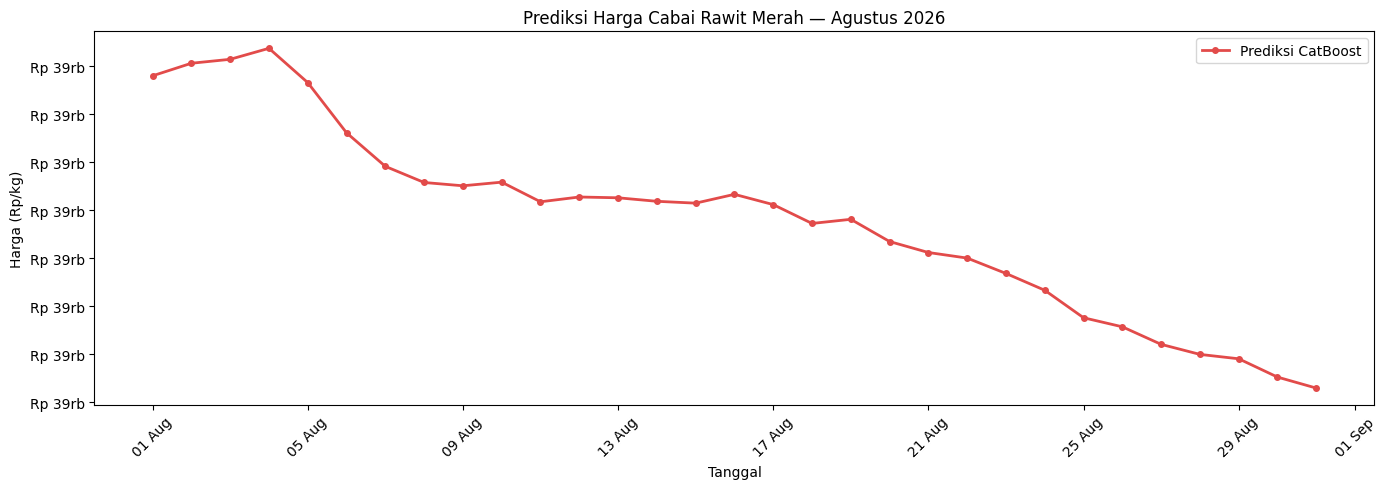

Rata-rata  : Rp 38,920/kg
Minimum    : Rp 38,832/kg
Maksimum   : Rp 39,009/kg


In [38]:
nama_bulan = f'{NAMA_BULAN[bulan]} {tahun}'
p = df_iklim['Prediksi']

plt.figure(figsize=(14, 5))
plt.plot(df_iklim['Tanggal'], p, color='#E24B4A', linewidth=2,
         marker='o', markersize=4, label='Prediksi CatBoost', zorder=3)

aktual_tgl = [pd.Timestamp(date(tahun, bulan, d))
              for d in range(1, last_day+1) if date(tahun, bulan, d) in aktual_dict]
if aktual_tgl:
    plt.plot(aktual_tgl, [aktual_dict[t.date()] for t in aktual_tgl],
             color='#1D9E75', linewidth=2, marker='s', markersize=5,
             label='Harga Aktual', zorder=4)

judul = f'Prediksi Harga Cabai Rawit Merah — {nama_bulan}'
plt.title(judul)
plt.xlabel('Tanggal'); plt.ylabel('Harga (Rp/kg)')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}rb'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Rata-rata  : Rp {p.mean():,.0f}/kg')
print(f'Minimum    : Rp {p.min():,.0f}/kg')
print(f'Maksimum   : Rp {p.max():,.0f}/kg')

### 8.3 Ringkasan Akurasi Model

In [39]:
mae_final  = mean_absolute_error(harga_test_aktual.values, y_pred)
rmse_final = np.sqrt(mean_squared_error(harga_test_aktual.values, y_pred))
r2_final   = r2_score(harga_test_aktual.values, y_pred)
mape_final = mean_absolute_percentage_error(harga_test_aktual.values, y_pred) * 100

print(f'MAE  : Rp {mae_final:,.0f}/kg')
print(f'RMSE : Rp {rmse_final:,.0f}/kg')
print(f'R²   : {r2_final:.4f}')
print(f'MAPE : {mape_final:.2f}%')

MAE  : Rp 1,044/kg
RMSE : Rp 3,659/kg
R²   : 0.9647
MAPE : 1.83%
